In [1]:
import pandas as pd
import os
import numpy as np

root_dir=os.path.join('c:/Users','sa01ld','OneDrive - SAMS','Cruises','CE24006 (TC24015) - ODISSSEA','Fetch')
infile=os.path.join(root_dir,"ExportData_2024Apr23_161705_LAT_LONG_OBS.csv")
outcsv=os.path.join(root_dir,"2024Apr23_161705_2312_CE24006_FETCH_DEPLOY.csv")
infile

'c:/Users\\sa01ld\\OneDrive - SAMS\\Cruises\\CE24006 (TC24015) - ODISSSEA\\Fetch\\ExportData_2024Apr23_161705_LAT_LONG_OBS.csv'

In [2]:
ds=pd.read_csv(infile,skiprows=3,
            usecols=[3,7,10,11,12],
            names=['Source','TimeStamp','Lat','Lon','Altitude'],
            index_col='TimeStamp')
ds.head()


,Source,Lat,Lon,Altitude
TimeStamp,,,,
2024-04-23 14:00:29.708,GPS 1,53.091184,-15.093980,86.610
2024-04-23 14:00:30.708,GPS 1,53.091187,-15.093980,86.656
2024-04-23 14:00:32.000,GPS 1,53.091185,-15.093984,86.622
2024-04-23 14:00:33.000,GPS 1,53.091180,-15.093988,86.503
2024-04-23 14:00:34.000,GPS 1,53.091175,-15.093990,86.342


In [3]:
fetch = ds[ds["Source"] =='2312']
ship = ds[ds["Source"] =='GPS 1']

In [4]:
fetch.tail()

,Source,Lat,Lon,Altitude
TimeStamp,,,,
2024-04-23 15:04:51.334,2312,53.092325,-15.093605,-1806.704871
2024-04-23 15:04:53.271,2312,53.092325,-15.093602,-1806.908452
2024-04-23 15:04:55.280,2312,53.092315,-15.093587,-1807.061482
2024-04-23 15:04:59.297,2312,53.092324,-15.093596,-1806.869199
2024-04-23 15:05:01.296,2312,53.092314,-15.093596,-1807.015699


In [16]:
import matplotlib.pyplot as plt
from matplotlib import ticker

end_location=[np.round(fetch.Lat[-1],4), np.round(fetch.Lon[-1],4)]
title_string='Seabed location  ' + str(end_location[0]) + ', ' + str(end_location[1]) + ' Depth = ' + str(np.round(fetch.Altitude[-1],1)*-1) + ' m'
title_string

'Seabed location  53.0923, -15.0936 Depth = 1807.0 m'

In [14]:
end_location

[53.092, -15.094]

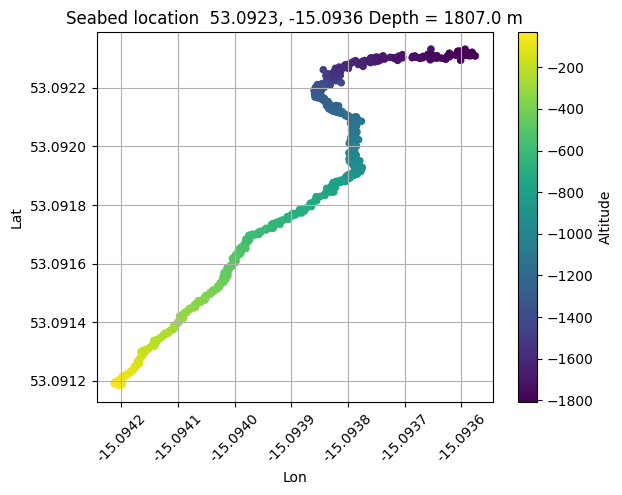

In [17]:
ax2 = fetch.plot.scatter(x='Lon',
                         y='Lat',
                         c='Altitude',
                         colormap='viridis',
                        grid=True,
                        rot=45,
                        title=title_string)
ax2.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.4f}"))
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.4f}"))